In [1]:
import torch
import torch.nn as nn
from torchvision import transforms, models
from torchvision.models import resnet18, efficientnet_b0, efficientnet_b3, mobilenet_v3_small
import pandas as pd
import numpy as np
from PIL import Image
from pathlib import Path
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report
import timm, json

BASE   = Path(r"C:\Users\npd20\Downloads\ĐACN_v2")
MODELS = BASE / "models"
FIGS   = BASE / "reports" / "figures"
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

SCORES = sorted(
    [f"{i}.{d}" for i in range(0, 10) for d in [0, 3, 5, 8]] + ["10"],
    key=lambda x: float(x)
)
label2idx = {s: i for i, s in enumerate(SCORES)}
idx2label = {i: s for s, i in label2idx.items()}

val_transform = transforms.Compose([
    transforms.Resize((64, 64)),
    transforms.ToTensor(),
    transforms.Normalize([0.5], [0.5])
])
deit_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize([0.5], [0.5])
])

print(f"Device: {DEVICE} | Classes: {len(SCORES)}")

Device: cuda | Classes: 41


#  Load tất cả models:

In [2]:
class CNNBaseline(nn.Module):
    def __init__(self, num_classes=41):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(3, 32, 3, padding=1), nn.BatchNorm2d(32), nn.ReLU(), nn.MaxPool2d(2),
            nn.Conv2d(32, 64, 3, padding=1), nn.BatchNorm2d(64), nn.ReLU(), nn.MaxPool2d(2),
            nn.Conv2d(64, 128, 3, padding=1), nn.BatchNorm2d(128), nn.ReLU(), nn.MaxPool2d(2),
            nn.Conv2d(128, 256, 3, padding=1), nn.BatchNorm2d(256), nn.ReLU(), nn.AdaptiveAvgPool2d(1),
        )
        self.classifier = nn.Sequential(
            nn.Flatten(), nn.Dropout(0.3), nn.Linear(256, num_classes)
        )
    def forward(self, x):
        return self.classifier(self.features(x))

def load_all_models():
    defs = {
        "CNN_Baseline":    CNNBaseline(),
        "ResNet18":        resnet18(weights=None),
        "EfficientNet_B0": efficientnet_b0(weights=None),
        "EfficientNet_B3": efficientnet_b3(weights=None),
        "MobileNetV3":     mobilenet_v3_small(weights=None),
        "DeiT_Tiny":       timm.create_model("deit_tiny_patch16_224", pretrained=False, num_classes=41),
    }
    # Fix heads
    defs["ResNet18"].fc                = nn.Linear(defs["ResNet18"].fc.in_features, 41)
    defs["EfficientNet_B0"].classifier[1] = nn.Linear(defs["EfficientNet_B0"].classifier[1].in_features, 41)
    defs["EfficientNet_B3"].classifier[1] = nn.Linear(defs["EfficientNet_B3"].classifier[1].in_features, 41)
    defs["MobileNetV3"].classifier[3]     = nn.Linear(defs["MobileNetV3"].classifier[3].in_features, 41)

    loaded = {}
    for name, model in defs.items():
        path = MODELS / f"{name}.pth"
        model.load_state_dict(torch.load(path, map_location=DEVICE))
        model = model.to(DEVICE)
        model.eval()
        loaded[name] = model
        print(f"✅ {name} loaded")
    return loaded

all_models = load_all_models()

✅ CNN_Baseline loaded
✅ ResNet18 loaded
✅ EfficientNet_B0 loaded
✅ EfficientNet_B3 loaded
✅ MobileNetV3 loaded
✅ DeiT_Tiny loaded


# Load external test set và predict:

In [3]:
def predict_single(model, img_path, is_deit=False):
    transform = deit_transform if is_deit else val_transform
    img = Image.open(img_path).convert("RGB")
    tensor = transform(img).unsqueeze(0).to(DEVICE)
    with torch.no_grad():
        out = model(tensor)
        prob = torch.softmax(out, dim=1)
        pred_idx = prob.argmax(1).item()
        confidence = prob.max().item()
    return idx2label[pred_idx], confidence

# Load external test
df1 = pd.read_csv(BASE / "Test_Phieu_01" / "external_test_labels.csv")
df2 = pd.read_csv(BASE / "Test_Phieu_02" / "external_test_labels.csv")
df_ext = pd.concat([df1, df2]).reset_index(drop=True)
df_valid = df_ext.dropna(subset=["label"]).copy()
df_valid["label_str"] = df_valid["label"].apply(
    lambda x: "10" if str(x) == "10.0" else str(x)
)

print(f"External test: {len(df_valid)} valid samples")

# Predict với tất cả models
for name, model in all_models.items():
    is_deit = (name == "DeiT_Tiny")
    preds, confs = [], []
    for _, row in df_valid.iterrows():
        pred, conf = predict_single(model, row["image_path"], is_deit)
        preds.append(pred)
        confs.append(conf)
    df_valid[f"pred_{name}"] = preds
    df_valid[f"conf_{name}"] = confs

# Accuracy per model
print("\nExternal Test Accuracy:")
print("-" * 40)
for name in all_models:
    correct = (df_valid[f"pred_{name}"] == df_valid["label_str"]).sum()
    acc = correct / len(df_valid)
    print(f"  {name:20s}: {correct}/{len(df_valid)} = {acc:.4f}")

External test: 75 valid samples

External Test Accuracy:
----------------------------------------
  CNN_Baseline        : 40/75 = 0.5333
  ResNet18            : 50/75 = 0.6667
  EfficientNet_B0     : 58/75 = 0.7733
  EfficientNet_B3     : 50/75 = 0.6667
  MobileNetV3         : 30/75 = 0.4000
  DeiT_Tiny           : 59/75 = 0.7867


#  Error analysis để biết model nhầm ở đâu:

DeiT_Tiny sai: 16/75

Nhầm nhiều nhất:
error
9.5 → 2.5    3
8.5 → 7.5    3
8.0 → 5.0    2
8.3 → 7.3    2
7.0 → 10     1
6.8 → 5.8    1
8.0 → 5.8    1
8.0 → 7.0    1
6.0 → 5.0    1
8.5 → 5.5    1
Name: count, dtype: int64


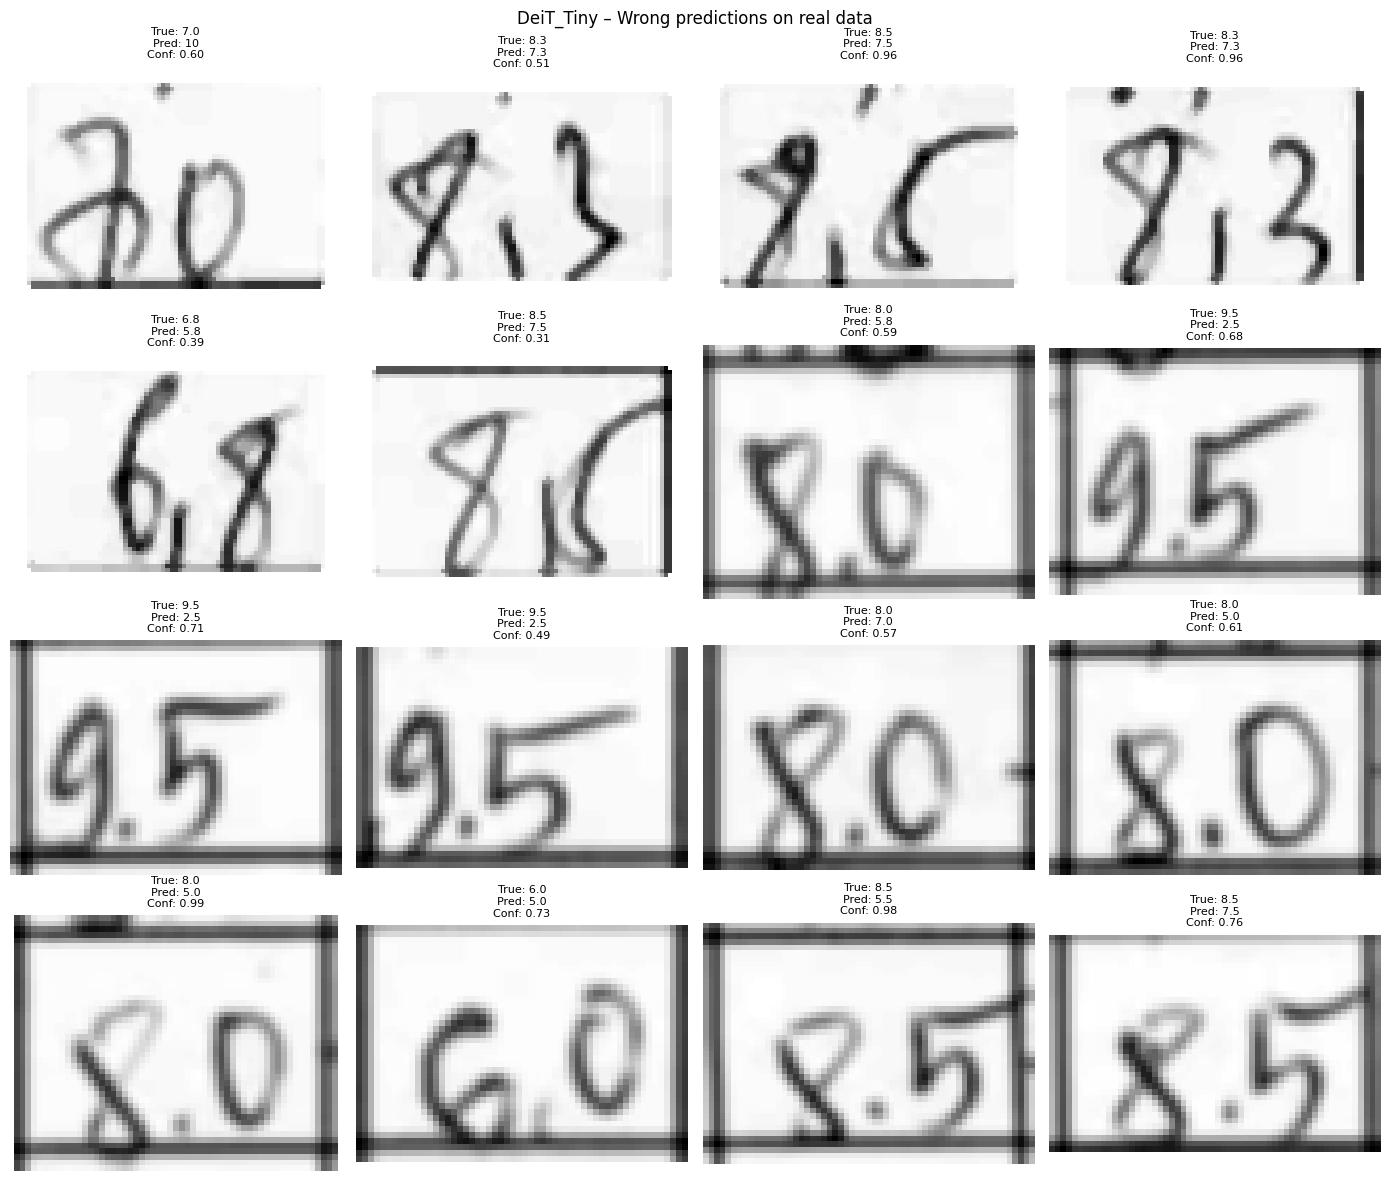

In [4]:
# Xem những ảnh bị nhầm của model tốt nhất (DeiT)
best_model = "DeiT_Tiny"
df_wrong = df_valid[df_valid[f"pred_{best_model}"] != df_valid["label_str"]].copy()

print(f"DeiT_Tiny sai: {len(df_wrong)}/75")
print("\nNhầm nhiều nhất:")
df_wrong["error"] = df_wrong["label_str"] + " → " + df_wrong[f"pred_{best_model}"]
print(df_wrong["error"].value_counts().head(10))

# Visualize ảnh sai
fig, axes = plt.subplots(4, 4, figsize=(14, 12))
for ax, (_, row) in zip(axes.flatten(), df_wrong.iterrows()):
    img = Image.open(row["image_path"])
    ax.imshow(img, cmap="gray")
    ax.set_title(
        f"True: {row['label_str']}\nPred: {row[f'pred_{best_model}']}\nConf: {row[f'conf_{best_model}']:.2f}",
        fontsize=8
    )
    ax.axis("off")

# Tắt axes thừa
for ax in axes.flatten()[len(df_wrong):]:
    ax.axis("off")

plt.suptitle(f"DeiT_Tiny – Wrong predictions on real data", fontsize=12)
plt.tight_layout()
plt.savefig(FIGS / "external_error_analysis.png", dpi=100)
plt.show()

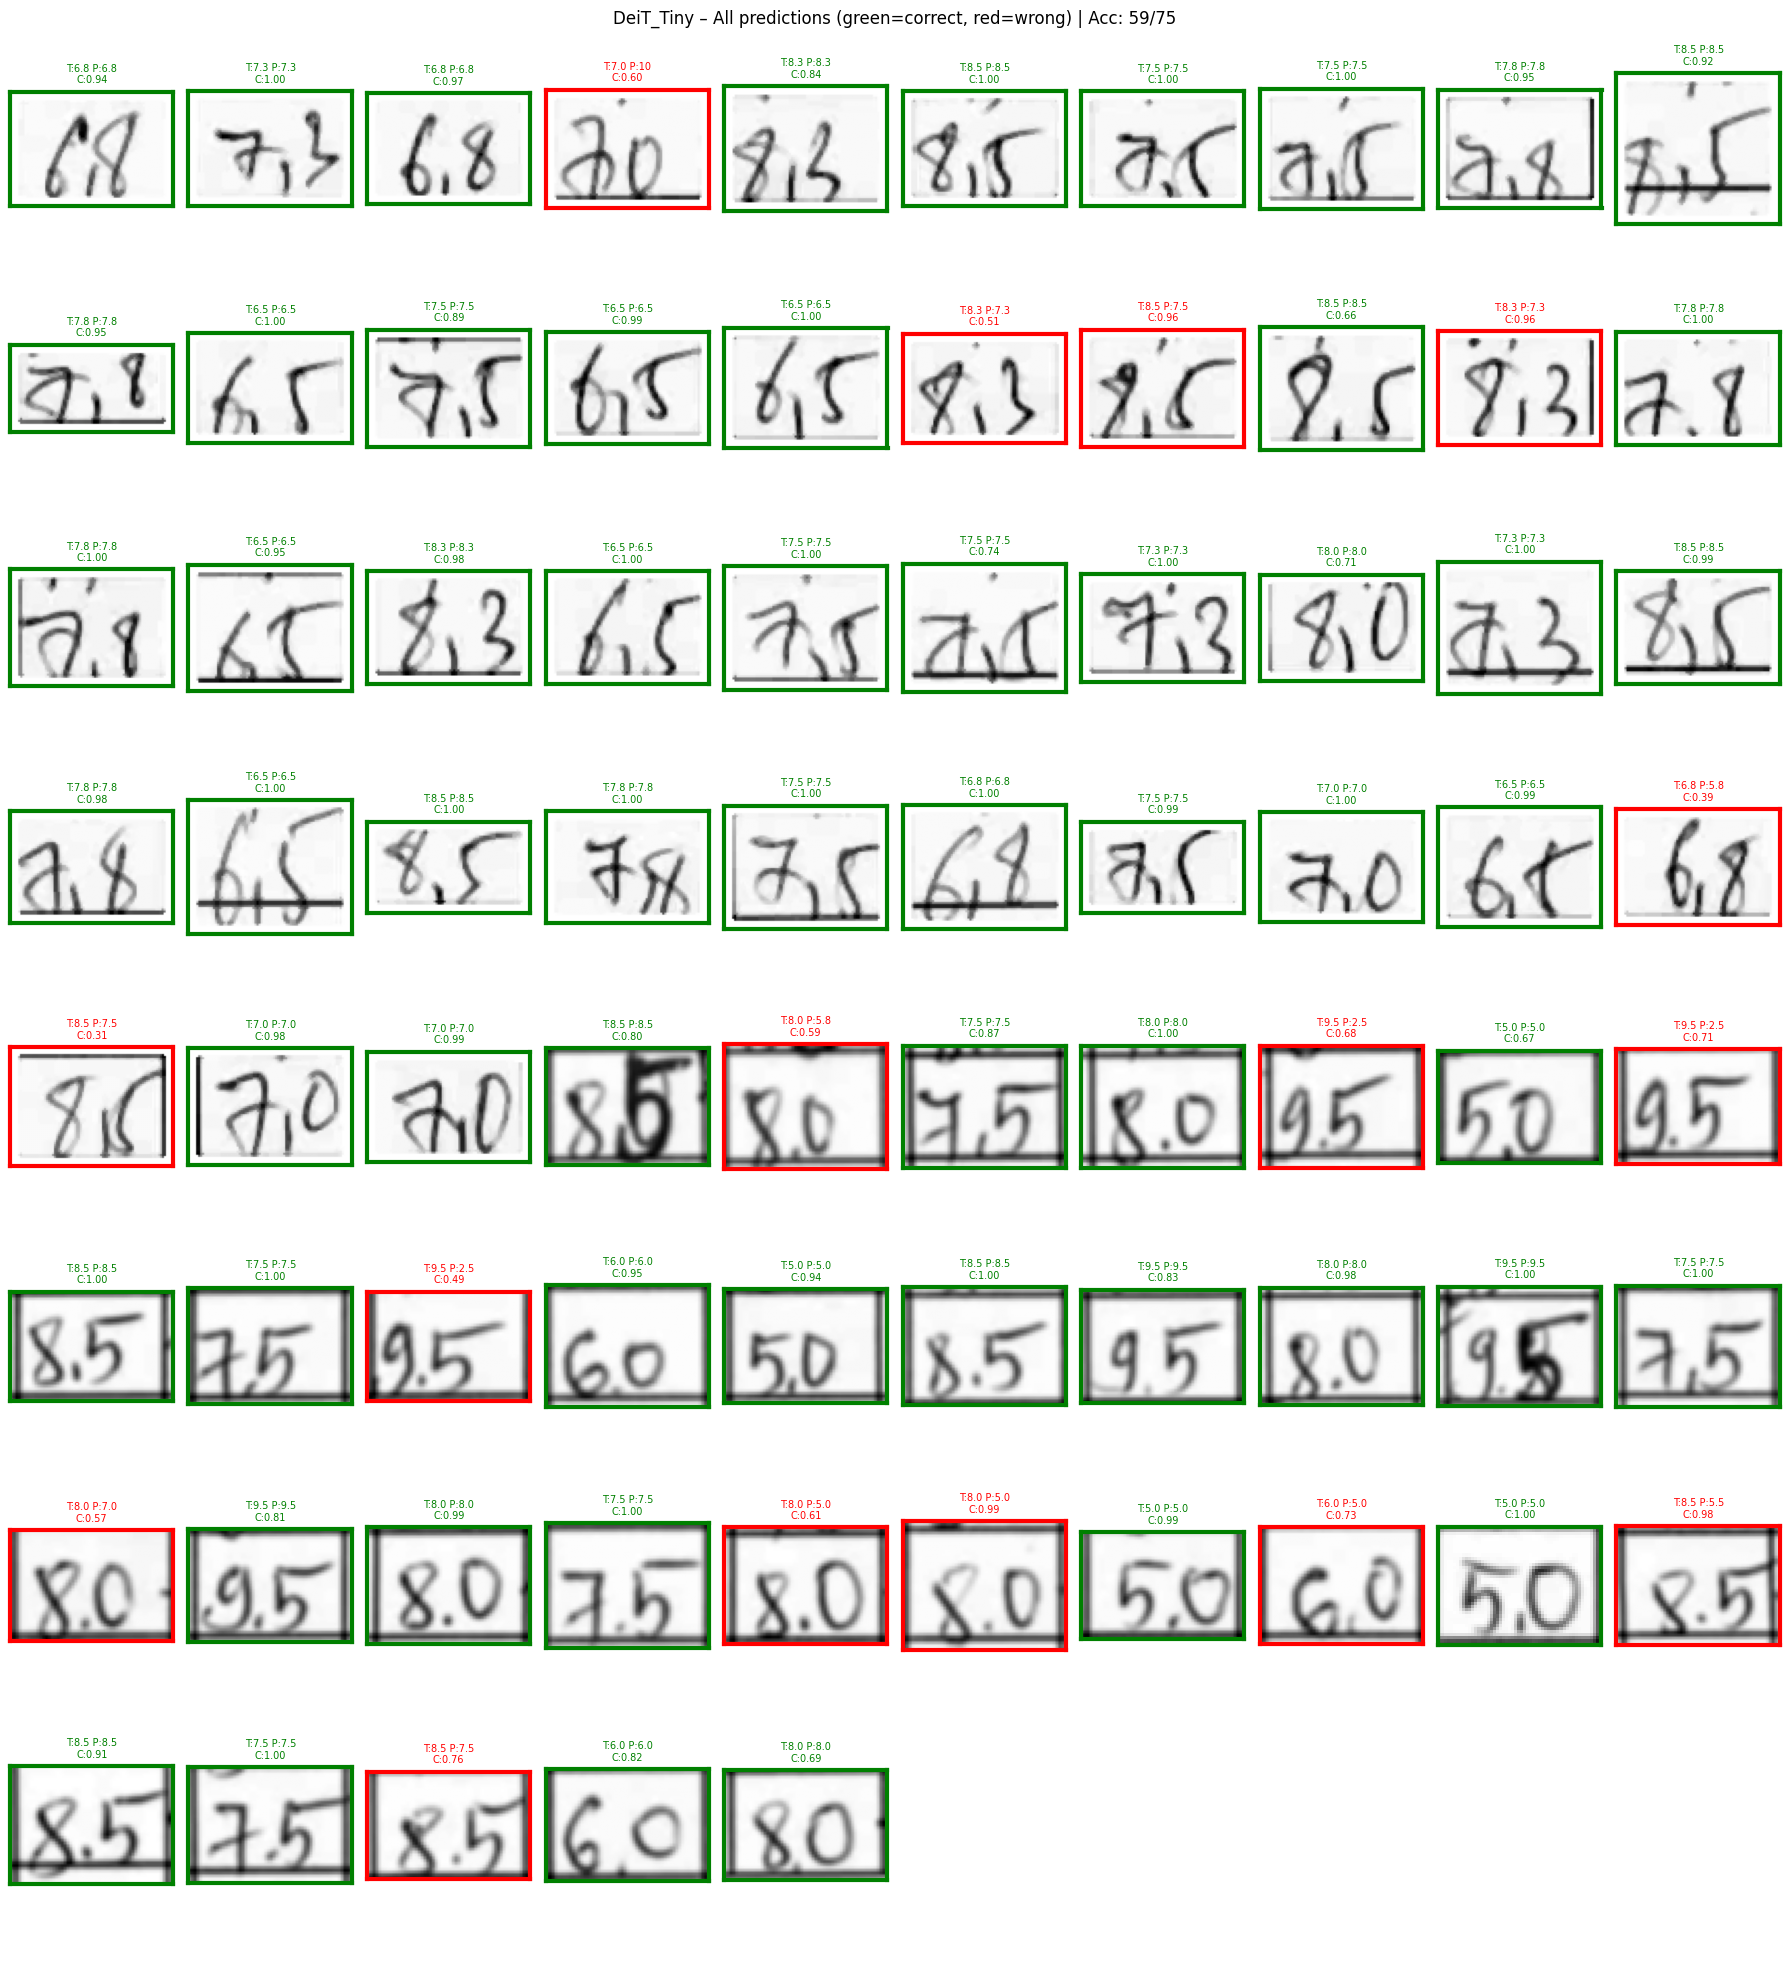

In [6]:
best_model = "DeiT_Tiny"
df_correct = df_valid[df_valid[f"pred_{best_model}"] == df_valid["label_str"]].copy()
df_wrong   = df_valid[df_valid[f"pred_{best_model}"] != df_valid["label_str"]].copy()

fig, axes = plt.subplots(len(df_valid)//10 + 1, 10, figsize=(18, 2.5 * (len(df_valid)//10 + 1)))
axes = axes.flatten()

for i, (_, row) in enumerate(df_valid.iterrows()):
    img = Image.open(row["image_path"])
    axes[i].imshow(img, cmap="gray")
    is_correct = row[f"pred_{best_model}"] == row["label_str"]
    color = "green" if is_correct else "red"
    axes[i].set_title(
        f"T:{row['label_str']} P:{row[f'pred_{best_model}']}\nC:{row[f'conf_{best_model}']:.2f}",
        fontsize=7, color=color
    )
    for spine in axes[i].spines.values():
        spine.set_edgecolor(color)
        spine.set_linewidth(3)
    axes[i].tick_params(left=False, bottom=False, labelleft=False, labelbottom=False)

for ax in axes[len(df_valid):]:
    ax.axis("off")

plt.suptitle(f"DeiT_Tiny – All predictions (green=correct, red=wrong) | Acc: {len(df_correct)}/{len(df_valid)}", 
             fontsize=12)
plt.tight_layout()
plt.savefig(FIGS / "all_predictions.png", dpi=100)
plt.show()

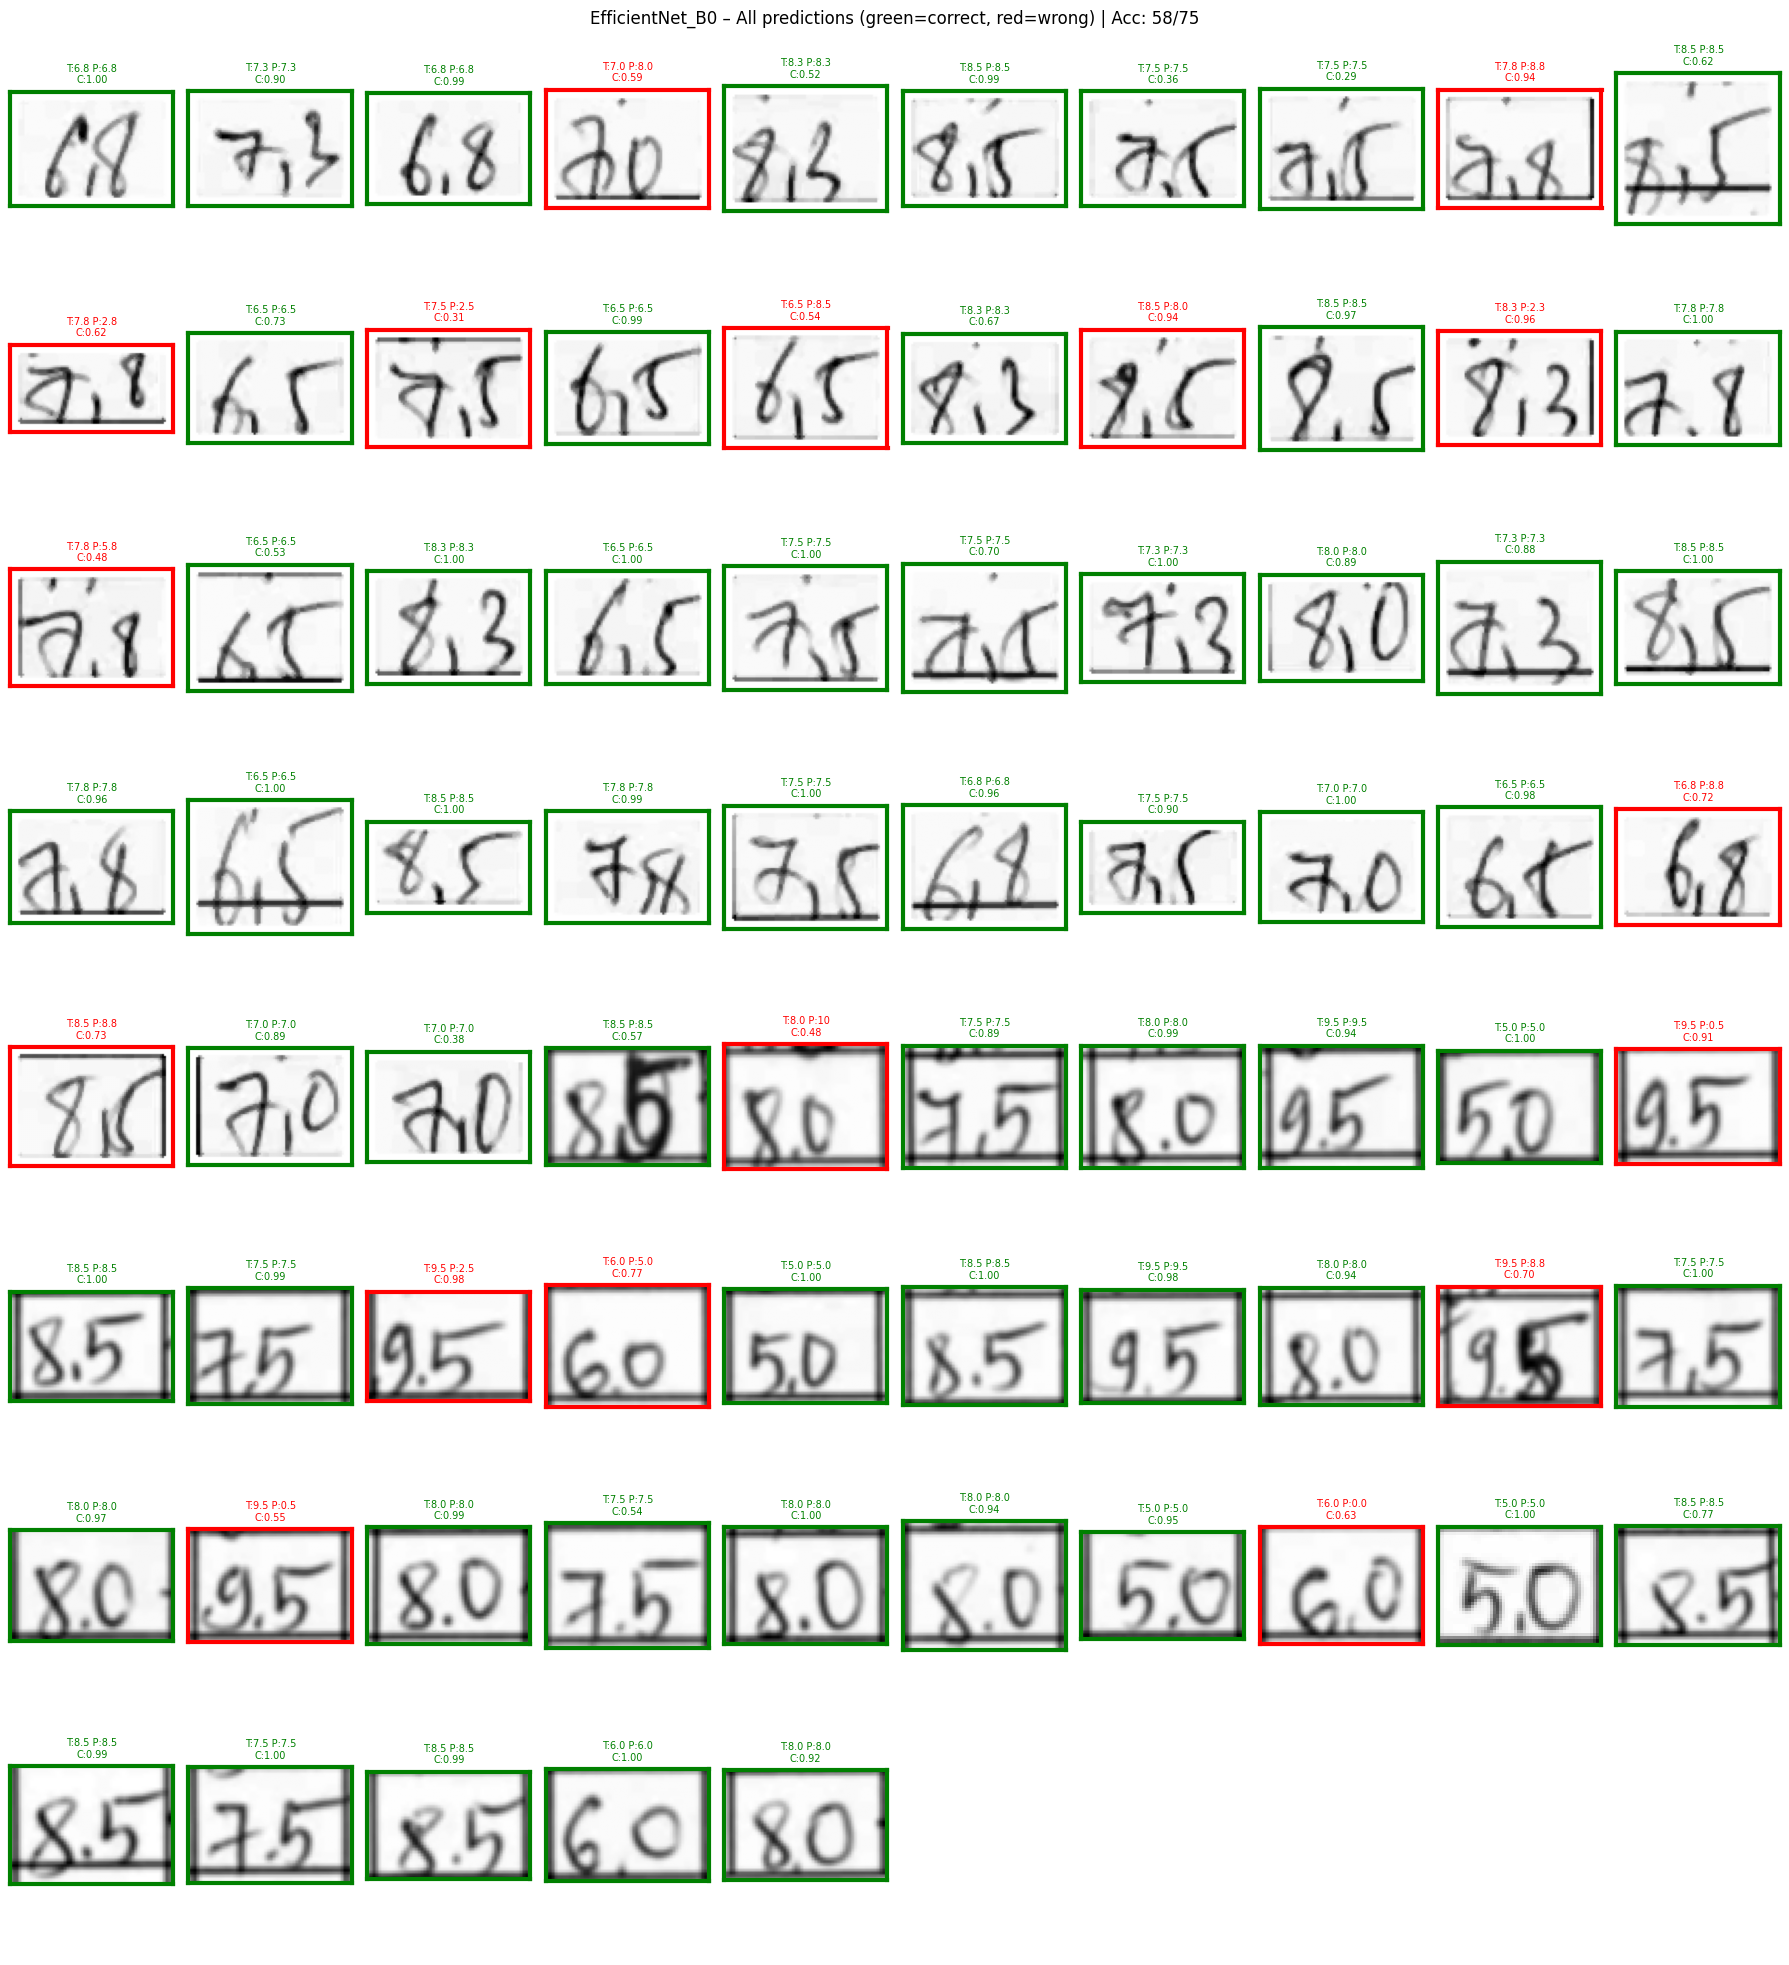

In [7]:
best_model = "EfficientNet_B0"
df_correct = df_valid[df_valid[f"pred_{best_model}"] == df_valid["label_str"]].copy()
df_wrong   = df_valid[df_valid[f"pred_{best_model}"] != df_valid["label_str"]].copy()

fig, axes = plt.subplots(len(df_valid)//10 + 1, 10, figsize=(18, 2.5 * (len(df_valid)//10 + 1)))
axes = axes.flatten()

for i, (_, row) in enumerate(df_valid.iterrows()):
    img = Image.open(row["image_path"])
    axes[i].imshow(img, cmap="gray")
    is_correct = row[f"pred_{best_model}"] == row["label_str"]
    color = "green" if is_correct else "red"
    axes[i].set_title(
        f"T:{row['label_str']} P:{row[f'pred_{best_model}']}\nC:{row[f'conf_{best_model}']:.2f}",
        fontsize=7, color=color
    )
    for spine in axes[i].spines.values():
        spine.set_edgecolor(color)
        spine.set_linewidth(3)
    axes[i].tick_params(left=False, bottom=False, labelleft=False, labelbottom=False)

for ax in axes[len(df_valid):]:
    ax.axis("off")

plt.suptitle(f"EfficientNet_B0 – All predictions (green=correct, red=wrong) | Acc: {len(df_correct)}/{len(df_valid)}",
             fontsize=12)
plt.tight_layout()
plt.savefig(FIGS / "all_predictions_effb0.png", dpi=100)
plt.show()

Kết luận: Model nhầm chủ yếu ở digit trái – phần decimal hầu như đúng. Đây là domain gap giữa chữ viết tay Kaggle (Latin style) và chữ viết tay Việt Nam.

# Comparison chart tổng hợp:

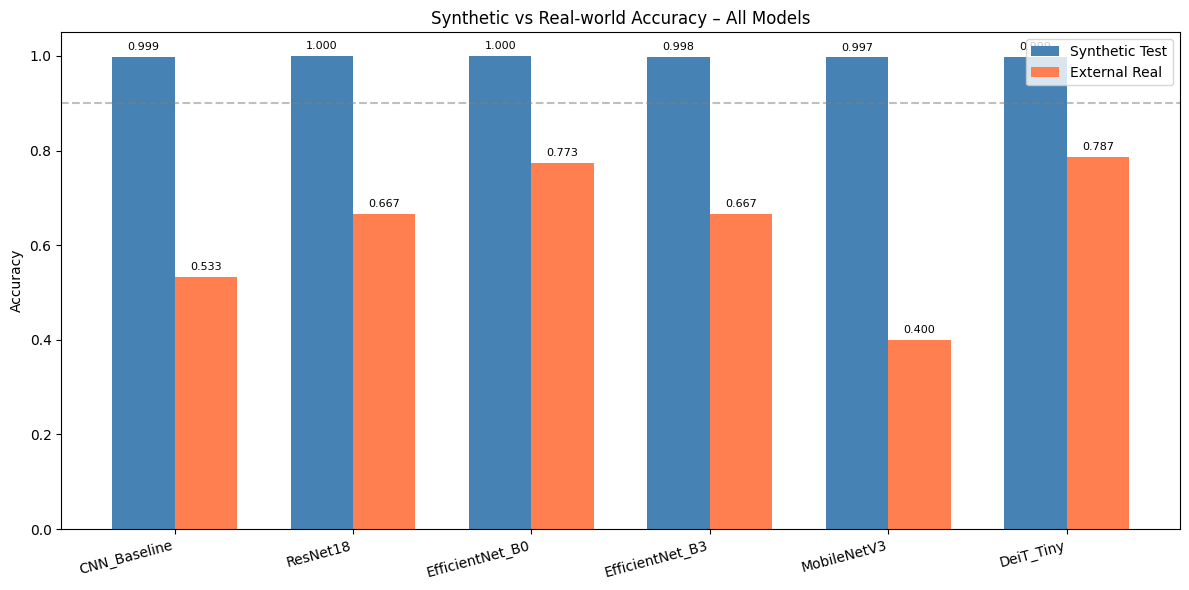

          model  synthetic_acc  external_acc    gap
   CNN_Baseline         0.9987        0.5333 0.4654
       ResNet18         0.9997        0.6667 0.3330
EfficientNet_B0         0.9998        0.7733 0.2265
EfficientNet_B3         0.9977        0.6667 0.3310
    MobileNetV3         0.9970        0.4000 0.5970
      DeiT_Tiny         0.9989        0.7867 0.2122


In [5]:
model_names = list(all_models.keys())
synthetic_acc = [0.9987, 0.9997, 0.9998, 0.9977, 0.9970, 0.9989]
external_acc  = [0.5333, 0.6667, 0.7733, 0.6667, 0.4000, 0.7867]

x = np.arange(len(model_names))
width = 0.35

fig, ax = plt.subplots(figsize=(12, 6))
bars1 = ax.bar(x - width/2, synthetic_acc, width, label='Synthetic Test', color='steelblue')
bars2 = ax.bar(x + width/2, external_acc,  width, label='External Real',  color='coral')

ax.set_ylabel('Accuracy')
ax.set_title('Synthetic vs Real-world Accuracy – All Models')
ax.set_xticks(x)
ax.set_xticklabels(model_names, rotation=15, ha='right')
ax.set_ylim(0, 1.05)
ax.legend()
ax.axhline(y=0.9, color='gray', linestyle='--', alpha=0.5, label='90% line')

# Value labels
for bar in bars1:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
            f'{bar.get_height():.3f}', ha='center', va='bottom', fontsize=8)
for bar in bars2:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
            f'{bar.get_height():.3f}', ha='center', va='bottom', fontsize=8)

plt.tight_layout()
plt.savefig(FIGS / "model_comparison.png", dpi=100)
plt.show()

# Save summary
summary = pd.DataFrame({
    "model": model_names,
    "synthetic_acc": synthetic_acc,
    "external_acc": external_acc,
    "gap": [s-e for s,e in zip(synthetic_acc, external_acc)]
})
summary.to_csv(BASE / "reports" / "model_summary.csv", index=False)
print(summary.to_string(index=False))